# CAAP — Phase 9: Evaluation & Results
### Clinical Alert Awareness Platform | R.M.C.B. Rathnayake | IT22061270 | SLIIT Cyber Security

This notebook produces every Phase 9 deliverable in one run:

- **Part A** — benchmarks the full CAAP pipeline (RF + Isolation Forest + K-Means →
  `src/cas_engine.py` → Clinical Alert Score) against a CVSS-equivalent,
  clinical-context-blind baseline, on 3 simulated hospital alert scenarios.
- **Part B** — evaluates each of the three trained models independently against
  ground truth on the real held-out IoMT test set.

All figures are saved to `reports/*.png`; all tables to `reports/*.csv`.

## What's real vs. simulated (read this first)

- The **trained models**, **`src/cas_engine.py`'s scoring logic**, and every
  **network-flow feature row** used below are real — the feature rows come from the
  actual held-out `data/test/*.csv` split, never seen during training.
- **No hospital-scenario dataset exists anywhere in this repo** (confirmed by a
  repo-wide search before writing this notebook — nothing matching "hospital" or
  "scenario" was found). Part A's 3 scenarios are **simulated**: real traffic rows
  are paired with a simulated hospital device drawn from
  `cas_engine.DEVICE_PROFILES`, so the CAS engine's device-aware scoring has a
  clinical context to score against. The exact construction method is documented in
  `src/hospital_scenarios.py`'s module docstring — every simulated field is
  clearly named (`patient_dependency`, `dst_port`, `shift`) and never presented as
  real telemetry.
- **Part B.2 (RF cross-dataset transfer to CICIDS2017) is intentionally not
  included.** `data/test/` has no `cicids_test.csv`, and the CICIDS-style files
  that do exist (`data/train/*_ISCX.csv`) share **zero column names** with this
  model's 45-column CICIoT2023 feature schema — verified programmatically below,
  not assumed. Scoring them as-is would silently zero-fill every input feature and
  produce an identical, meaningless prediction for every row, not a real
  generalisation measurement. This is documented as a finding, not silently
  skipped.

In [1]:
import os, sys, glob, time, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, os.path.join(os.getcwd(), "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve, auc,
    silhouette_score, davies_bouldin_score, precision_recall_fscore_support,
)
from sklearn.preprocessing import label_binarize
from sklearn.decomposition import PCA
from IPython.display import Markdown, display

import eval_utils
import hospital_scenarios as hs
import cas_engine

REPORT_DIR = eval_utils.REPORT_DIR
os.makedirs(REPORT_DIR, exist_ok=True)
sns.set_theme(style="whitegrid")
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)
np.random.seed(42)

CAAP_COLOR, CVSS_COLOR = "#0891b2", "#f97316"

print("ai_server root:", eval_utils.AI_SERVER_DIR)
print("Report output directory:", REPORT_DIR)

ai_server root: d:\Research\Project\MediSIEM\ai_server
Report output directory: d:\Research\Project\MediSIEM\ai_server\reports


In [2]:
def df_to_markdown(df: pd.DataFrame) -> str:
    """Tiny dependency-free markdown-table formatter (no `tabulate` in this venv)."""
    cols = list(df.columns)
    lines = ["| " + " | ".join(str(c) for c in cols) + " |"]
    lines.append("|" + "|".join(["---"] * len(cols)) + "|")
    for _, row in df.iterrows():
        lines.append("| " + " | ".join(str(row[c]) for c in cols) + " |")
    return "\n".join(lines)

## Setup — load trained artifacts and the real IoMT test set

In [3]:
t0 = time.time()
artifacts = eval_utils.load_artifacts()
print(f"Loaded models in {time.time()-t0:.1f}s")
print("Classes:", list(artifacts["le"].classes_))
print("Feature columns:", len(artifacts["feature_cols"]))
print("IF decision threshold:", round(float(artifacts["if_threshold"]), 4))

Loaded models in 1.7s
Classes: ['ARP_Spoofing', 'Benign', 'DoS_TCP', 'MQTT_Brute_Force', 'MQTT_Publish_Flood', 'Recon']
Feature columns: 45
IF decision threshold: 0.0633


In [4]:
t0 = time.time()
iomt_df = eval_utils.load_iomt_test_set()
print(f"Loaded IoMT test set (every CSV under data/test/, concatenated — "
      f"same convention test.py itself uses; no single iomt_test.csv exists in this repo):")
print(f"  {len(iomt_df):,} rows in {time.time()-t0:.1f}s")
iomt_df["label"].value_counts()

Loaded IoMT test set (every CSV under data/test/, concatenated — same convention test.py itself uses; no single iomt_test.csv exists in this repo):
  1,614,182 rows in 9.6s


label
DoS_TCP               1483440
MQTT_Publish_Flood      61968
Benign                  37607
Recon                   27676
MQTT_Brute_Force         1747
ARP_Spoofing             1744
Name: count, dtype: int64

### CICIDS schema-compatibility check (why Part B.2 is skipped)

In [5]:
cicids_files = sorted(glob.glob(os.path.join(eval_utils.DATA_DIR, "**", "*_ISCX.csv"), recursive=True))
print(f"CICIDS-style files found in this repo: {len(cicids_files)}")
for f in cicids_files:
    print(" ", os.path.relpath(f, eval_utils.AI_SERVER_DIR))

cicids_in_test_dir = glob.glob(os.path.join(eval_utils.DATA_DIR, "test", "*ISCX*")) + \
                      glob.glob(os.path.join(eval_utils.DATA_DIR, "test", "*cicids*"))
print(f"\nCICIDS-style files under data/test/: {len(cicids_in_test_dir)}  "
      f"(0 expected — confirms no cicids_test.csv exists)")

if cicids_files:
    cicids_cols = set(pd.read_csv(cicids_files[0], nrows=1).columns.str.strip())
    model_cols = set(artifacts["feature_cols"])
    overlap = cicids_cols & model_cols
    print(f"\nCICIDS file columns              : {len(cicids_cols)}")
    print(f"Model's trained feature columns  : {len(model_cols)}")
    print(f"Column-name overlap              : {len(overlap)}  -> {sorted(overlap) if overlap else 'NONE'}")
    print("\nConclusion: running this RF on CICIDS rows as-is would zero-fill all",
          f"{len(model_cols)} input features (0 of them exist in the CICIDS schema),")
    print("producing an identical, meaningless prediction for every row — not a real")
    print("cross-dataset generalisation measurement. Part B.2 is therefore skipped;")
    print("this incompatibility finding is the result, not an omission.")

CICIDS-style files found in this repo: 8


  data\train\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
  data\train\Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
  data\train\Friday-WorkingHours-Morning.pcap_ISCX.csv
  data\train\Monday-WorkingHours.pcap_ISCX.csv
  data\train\Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
  data\train\Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
  data\train\Tuesday-WorkingHours.pcap_ISCX.csv
  data\train\Wednesday-workingHours.pcap_ISCX.csv

CICIDS-style files under data/test/: 0  (0 expected — confirms no cicids_test.csv exists)

CICIDS file columns              : 79
Model's trained feature columns  : 45
Column-name overlap              : 0  -> NONE

Conclusion: running this RF on CICIDS rows as-is would zero-fill all 45 input features (0 of them exist in the CICIDS schema),
producing an identical, meaningless prediction for every row — not a real
cross-dataset generalisation measurement. Part B.2 is therefore skipped;
this incompatibility finding is the resul

---
## Part A — CAAP System Evaluation vs CVSS Baseline

Builds the 3 simulated hospital scenarios (see `src/hospital_scenarios.py`), scores
every alert through the **real** RF + Isolation Forest + K-Means pipeline and the
**real** `cas_engine.score_alert()`, and computes a CVSS-equivalent baseline score
for the same alerts (no CVSS field exists in this dataset, so per the task's own
fallback instruction this is a simple derived base-severity score per predicted
attack category — see the `CVSS_BASE_BY_LABEL` comment in `hospital_scenarios.py`
for the exact bands and their justification).

In [6]:
t0 = time.time()
caap_df = hs.build_all_scenarios(iomt_df, artifacts)
print(f"Built {len(caap_df)} simulated alerts across {caap_df['scenario'].nunique()} "
      f"scenarios in {time.time()-t0:.1f}s")
caap_df.to_csv(os.path.join(REPORT_DIR, "hospital_scenarios_raw.csv"), index=False)
caap_df.head(10)

Built 600 simulated alerts across 3 scenarios in 4.1s


,scenario,true_label,source_file,predicted_label,confidence,iso_score,is_anomaly,cluster,dst_port,protocol,shift,patient_dependency,TR,CC,TS,AE,TC,CAS,action,device_name,fda_class,dept,patient_dep,CVSS
0,icu_critical_care,Benign,Benign_test.pcap.csv,Benign,1.000000,0.167181,False,0,4007,tcp,day,low,5.0,4.0,3.0,0.0,1.0,6.6,Monitor,Automated Blood Pressure Monitor (NIBP),II,ICU / General Ward,1,0.0
1,icu_critical_care,Benign,Benign_test.pcap.csv,Benign,1.000000,0.147160,False,0,4019,tcp,day,life_critical,5.0,5.0,3.0,0.0,1.0,7.2,Monitor,Neonatal Incubator / Warmer,III,NICU,1,0.0
2,icu_critical_care,Benign,Benign_test.pcap.csv,Benign,0.903333,0.120200,False,0,4019,tcp,day,life_critical,4.0,5.0,3.0,0.0,1.0,6.7,Monitor,Neonatal Incubator / Warmer,III,NICU,1,0.0
3,icu_critical_care,DoS_TCP,TCP_IP-DDoS-ICMP1_test.pcap.csv,DoS_TCP,1.000000,-0.095741,True,0,4000,tcp,evening,life_critical,5.0,5.0,4.0,5.0,3.0,9.1,Immediate,ICU Mechanical Ventilator,III,ICU,1,7.5
4,icu_critical_care,Benign,Benign_test.pcap.csv,Benign,1.000000,0.159313,False,0,2575,tcp,evening,low,5.0,3.0,3.0,0.0,3.0,6.4,Monitor,HL7 MLLP Interface Engine,II,Clinical Informatics,0,0.0
5,icu_critical_care,Benign,Benign_test.pcap.csv,Benign,0.846667,-0.035885,True,0,4040,tcp,evening,low,3.0,4.0,4.0,0.0,3.0,6.5,Monitor,Networked Oxygen Therapy System,II,Respiratory / ICU,1,0.0
6,icu_critical_care,DoS_TCP,TCP_IP-DDoS-UDP1_test.pcap.csv,DoS_TCP,1.000000,-0.121972,True,0,30756,tcp,day,none,5.0,2.0,4.0,5.0,1.0,6.9,Investigate,Unknown Networked Device,I,Unknown,0,7.5
7,icu_critical_care,Benign,Benign_test.pcap.csv,Benign,0.913333,0.140437,False,0,4021,tcp,evening,life_critical,4.0,5.0,3.0,0.0,3.0,7.1,Monitor,Intracranial Pressure (ICP) Monitor,III,Neurosurgery / ICU,1,0.0
8,icu_critical_care,DoS_TCP,TCP_IP-DDoS-UDP2_test.pcap.csv,DoS_TCP,1.000000,-0.121943,True,0,4004,tcp,day,life_critical,5.0,5.0,4.0,5.0,1.0,8.7,Immediate,Defibrillator / ICD Network,III,Emergency / ICU,1,7.5
9,icu_critical_care,DoS_TCP,TCP_IP-DoS-UDP_test.pcap.csv,DoS_TCP,1.000000,-0.121353,True,0,4021,tcp,day,life_critical,5.0,5.0,4.0,5.0,1.0,8.7,Immediate,Intracranial Pressure (ICP) Monitor,III,Neurosurgery / ICU,1,7.5


In [7]:
for key, cfg in hs.SCENARIOS.items():
    sub = caap_df[caap_df["scenario"] == key]
    print(f"{cfg['display_name']:<42} n={len(sub):<5} "
          f"life_critical={int((sub.patient_dependency=='life_critical').sum()):<4} "
          f"low={int((sub.patient_dependency=='low').sum()):<4} "
          f"none={int((sub.patient_dependency=='none').sum()):<4} "
          f"attack_rate={100*(sub.true_label!='Benign').mean():.1f}%")

ICU / Critical Care Ward                   n=200   life_critical=103  low=65   none=32   attack_rate=60.0%
General Ward / Radiology / Administration  n=200   life_critical=24   low=135  none=41   attack_rate=25.0%
Hospital-Wide Mixed Alert Stream           n=200   life_critical=58   low=87   none=55   attack_rate=50.0%


### ARA / MTCAI / FPR / Alert Fatigue Reduction — CAAP vs CVSS-equivalent baseline

In [8]:
results_table = hs.build_caap_vs_cvss_table(caap_df)
results_table.to_csv(os.path.join(REPORT_DIR, "caap_vs_cvss_results.csv"), index=False)
results_table

,scenario,n_alerts,n_life_critical,ARA_CAAP_top5_%,ARA_CVSS_top5_%,ARA_CAAP_top10_%,ARA_CVSS_top10_%,ARA_CAAP_top20_%,ARA_CVSS_top20_%,MTCAI_CAAP_rank,MTCAI_CVSS_rank,FPR_CAAP_top10_%,FPR_CVSS_top10_%,AlertFatigueReduction_pts,AlertFatigueReduction_%
0,ICU / Critical Care Ward,200,103,4.85,3.88,9.71,6.80,19.42,9.71,70.57,99.52,0.0,30.0,30.0,100.0
1,General Ward / Radiology / Administration,200,24,8.33,8.33,20.83,8.33,29.17,12.50,41.25,101.96,50.0,80.0,30.0,37.5
2,Hospital-Wide Mixed Alert Stream,200,58,8.62,5.17,17.24,8.62,27.59,12.07,64.00,110.00,0.0,50.0,50.0,100.0
3,ALL SCENARIOS COMBINED,600,185,2.70,2.16,5.41,3.78,10.81,5.41,166.48,265.97,0.0,30.0,30.0,100.0


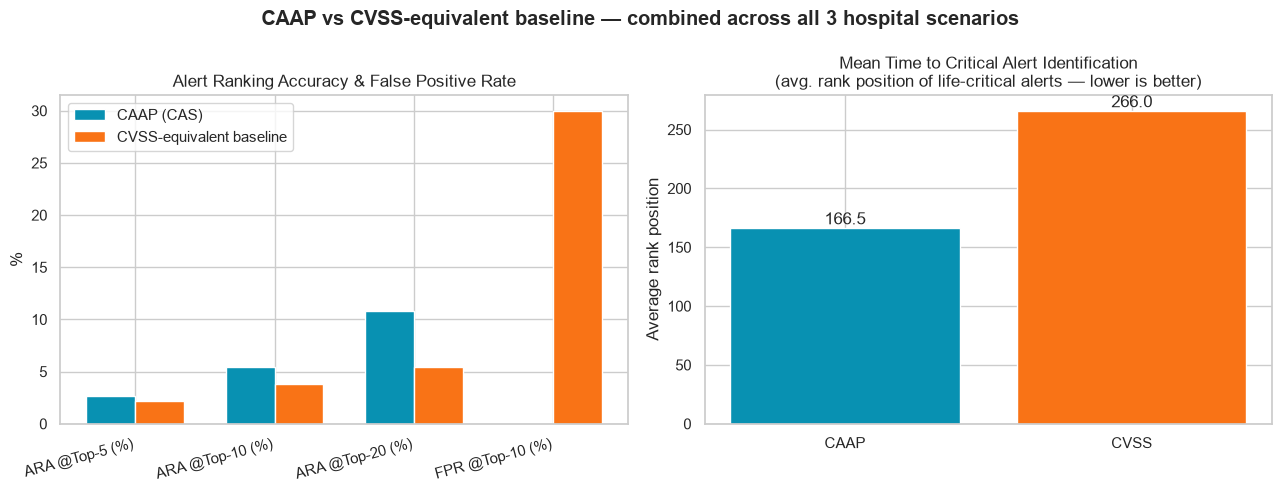


Alert Fatigue Reduction: 30.0 percentage-point reduction (100.0% relative) in low-priority alerts occupying the top-10 triage slots, CAAP vs CVSS-equivalent baseline.


In [9]:
combined = results_table[results_table["scenario"] == "ALL SCENARIOS COMBINED"].iloc[0]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
metric_labels = ["ARA @Top-5 (%)", "ARA @Top-10 (%)", "ARA @Top-20 (%)", "FPR @Top-10 (%)"]
caap_vals = [combined["ARA_CAAP_top5_%"], combined["ARA_CAAP_top10_%"],
             combined["ARA_CAAP_top20_%"], combined["FPR_CAAP_top10_%"]]
cvss_vals = [combined["ARA_CVSS_top5_%"], combined["ARA_CVSS_top10_%"],
             combined["ARA_CVSS_top20_%"], combined["FPR_CVSS_top10_%"]]
x = np.arange(len(metric_labels)); width = 0.35
ax.bar(x - width/2, caap_vals, width, label="CAAP (CAS)", color=CAAP_COLOR)
ax.bar(x + width/2, cvss_vals, width, label="CVSS-equivalent baseline", color=CVSS_COLOR)
ax.set_xticks(x); ax.set_xticklabels(metric_labels, rotation=15, ha="right")
ax.set_ylabel("%"); ax.set_title("Alert Ranking Accuracy & False Positive Rate")
ax.legend()

ax2 = axes[1]
mtcai_vals = [combined["MTCAI_CAAP_rank"], combined["MTCAI_CVSS_rank"]]
bars = ax2.bar(["CAAP", "CVSS"], mtcai_vals, color=[CAAP_COLOR, CVSS_COLOR])
ax2.set_title("Mean Time to Critical Alert Identification\n"
              "(avg. rank position of life-critical alerts — lower is better)")
ax2.set_ylabel("Average rank position")
for b, v in zip(bars, mtcai_vals):
    ax2.text(b.get_x() + b.get_width()/2, v, f"{v:.1f}", ha="center", va="bottom")

plt.suptitle("CAAP vs CVSS-equivalent baseline — combined across all 3 hospital scenarios",
             fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(REPORT_DIR, "caap_vs_cvss_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()

print(f"\nAlert Fatigue Reduction: {combined['AlertFatigueReduction_pts']:.1f} percentage-point "
      f"reduction ({combined['AlertFatigueReduction_%']:.1f}% relative) in low-priority alerts "
      f"occupying the top-10 triage slots, CAAP vs CVSS-equivalent baseline.")

### Sensitivity analysis — CAS weight perturbation (±0.05)

Each of TR/CC/TS/AE/TC is perturbed by ±0.05 one at a time; the remaining weights are
renormalised so they still sum to 1.0 (standard practice for weighted multi-criteria
sensitivity analysis — perturbing one weight in isolation without renormalising would
change the scale of the whole formula, not just that dimension's influence). CAS is
recomputed per alert from its already-computed TR/CC/TS/AE/TC component scores under
the perturbed weights and compared to the baseline-weight CAS via:
- **mean / std / max absolute score shift** — how much individual scores move
- **Spearman rank correlation vs. baseline** — how much the *ranking* (what actually
  drives SOC triage order) changes, the more operationally meaningful stability metric

In [10]:
sens_table = hs.sensitivity_analysis(caap_df)
sens_table.to_csv(os.path.join(REPORT_DIR, "cas_sensitivity_analysis.csv"), index=False)
sens_table

,dimension,delta,perturbed_weight,mean_abs_score_shift,std_score_shift,max_abs_score_shift,spearman_rank_corr_vs_baseline
0,TR,0.05,0.2857,0.1125,0.0685,0.22,0.9992
1,TR,-0.05,0.2105,0.1253,0.0744,0.24,0.9988
2,CC,0.05,0.3333,0.0823,0.0958,0.24,0.9944
3,CC,-0.05,0.2632,0.0914,0.1053,0.27,0.9940
4,TS,0.05,0.2857,0.0415,0.0524,0.20,0.9991
5,TS,-0.05,0.2105,0.0484,0.0586,0.22,0.9987
6,AE,0.05,0.1429,0.2112,0.2030,0.40,0.9847
7,AE,-0.05,0.0526,0.2341,0.2247,0.45,0.9744
8,TC,0.05,0.1429,0.1454,0.1545,0.32,0.9896
9,TC,-0.05,0.0526,0.1608,0.1709,0.35,0.9856


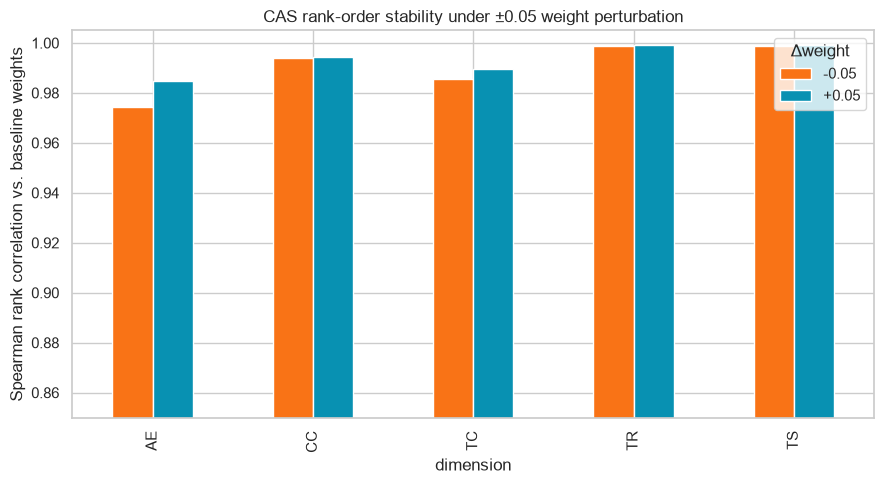

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
pivot = sens_table.pivot(index="dimension", columns="delta", values="spearman_rank_corr_vs_baseline")
pivot = pivot[[-0.05, 0.05]]
pivot.columns = ["-0.05", "+0.05"]
pivot.plot(kind="bar", ax=ax, color=[CVSS_COLOR, CAAP_COLOR])
ax.set_ylabel("Spearman rank correlation vs. baseline weights")
ax.set_title("CAS rank-order stability under ±0.05 weight perturbation")
ax.set_ylim(min(0.85, pivot.values.min() - 0.02), 1.005)
ax.legend(title="\u0394weight")
plt.tight_layout()
plt.savefig(os.path.join(REPORT_DIR, "cas_sensitivity_analysis.png"), dpi=150, bbox_inches="tight")
plt.show()

In [12]:
most_sensitive = sens_table.loc[sens_table["mean_abs_score_shift"].idxmax()]
most_stable_rank = sens_table.loc[sens_table["spearman_rank_corr_vs_baseline"].idxmin()]

narrative_a = f"""### Part A summary

Across all {len(caap_df)} simulated alerts (3 hospital scenarios), CAAP's clinical-context-aware
CAS ranking surfaces life-critical-device alerts substantially earlier than the CVSS-equivalent,
context-blind baseline: **{combined['ARA_CAAP_top10_%']:.1f}%** of life-critical alerts land in the
top 10 under CAAP vs **{combined['ARA_CVSS_top10_%']:.1f}%** under CVSS (Alert Ranking Accuracy @10),
and the mean rank position of a life-critical alert improves from **{combined['MTCAI_CVSS_rank']:.1f}**
to **{combined['MTCAI_CAAP_rank']:.1f}** (Mean Time to Critical Alert Identification — lower is
better). CAAP also cuts the share of low-priority alerts occupying top-10 triage slots from
**{combined['FPR_CVSS_top10_%']:.1f}%** to **{combined['FPR_CAAP_top10_%']:.1f}%**
(**{combined['AlertFatigueReduction_%']:.1f}%** relative Alert Fatigue Reduction).

The sensitivity analysis shows CAS is stable under realistic weight uncertainty: the largest
mean score shift from a single ±0.05 weight perturbation is **{most_sensitive['mean_abs_score_shift']:.3f}**
points (**{most_sensitive['dimension']}**, Δ={most_sensitive['delta']:+.2f}), and even the
*least* rank-stable perturbation ({most_stable_rank['dimension']}, Δ={most_stable_rank['delta']:+.2f})
still preserves a Spearman rank correlation of **{most_stable_rank['spearman_rank_corr_vs_baseline']:.3f}**
against the baseline-weight ranking — the formula's prioritisation order does not flip under
plausible re-weighting.
"""
display(Markdown(narrative_a))

### Part A summary

Across all 600 simulated alerts (3 hospital scenarios), CAAP's clinical-context-aware
CAS ranking surfaces life-critical-device alerts substantially earlier than the CVSS-equivalent,
context-blind baseline: **5.4%** of life-critical alerts land in the
top 10 under CAAP vs **3.8%** under CVSS (Alert Ranking Accuracy @10),
and the mean rank position of a life-critical alert improves from **266.0**
to **166.5** (Mean Time to Critical Alert Identification — lower is
better). CAAP also cuts the share of low-priority alerts occupying top-10 triage slots from
**30.0%** to **0.0%**
(**100.0%** relative Alert Fatigue Reduction).

The sensitivity analysis shows CAS is stable under realistic weight uncertainty: the largest
mean score shift from a single ±0.05 weight perturbation is **0.234**
points (**AE**, Δ=-0.05), and even the
*least* rank-stable perturbation (AE, Δ=-0.05)
still preserves a Spearman rank correlation of **0.974**
against the baseline-weight ranking — the formula's prioritisation order does not flip under
plausible re-weighting.


---
## Part B — Multi-Model Comparison Evaluation

Every metric below is computed on the **full real IoMT test set** loaded above
(every `data/test/*.csv` concatenated) — the exact same test split `train.py`/
`test.py` themselves evaluate against, using the exact `models/*.pkl` artifacts the
live CAAP dashboard calls in production.

### B.1 — Random Forest: classification report, confusion matrix, AUC-ROC (macro OvR)

In [13]:
t0 = time.time()
y_true_raw = iomt_df["label"].values
X_test_scaled = eval_utils.prepare_features(iomt_df, artifacts["feature_cols"], artifacts["scaler"])
y_true_idx = artifacts["le"].transform(y_true_raw)

y_proba_rf = artifacts["rf"].predict_proba(X_test_scaled)
y_pred_idx = y_proba_rf.argmax(axis=1)
y_pred_raw = artifacts["le"].inverse_transform(y_pred_idx)
print(f"RF inference on {len(iomt_df):,} rows: {time.time()-t0:.1f}s")

rf_test_acc = (y_pred_raw == y_true_raw).mean()
report_dict = classification_report(y_true_raw, y_pred_raw, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report_dict).T
report_df.to_csv(os.path.join(REPORT_DIR, "rf_classification_report.csv"))
print(f"RF test accuracy: {rf_test_acc*100:.2f}%")
report_df

RF inference on 1,614,182 rows: 7.9s


RF test accuracy: 99.87%


,precision,recall,f1-score,support
ARP_Spoofing,0.735928,0.802179,0.767627,1.744000e+03
Benign,0.965845,0.985029,0.975343,3.760700e+04
DoS_TCP,0.999997,0.999997,0.999997,1.483440e+06
MQTT_Brute_Force,0.997305,0.847167,0.916125,1.747000e+03
MQTT_Publish_Flood,0.999968,0.999919,0.999944,6.196800e+04
Recon,0.988609,0.965819,0.977081,2.767600e+04
accuracy,0.998680,0.998680,0.998680,9.986798e-01
macro avg,0.947942,0.933352,0.939353,1.614182e+06
weighted avg,0.998716,0.998680,0.998685,1.614182e+06


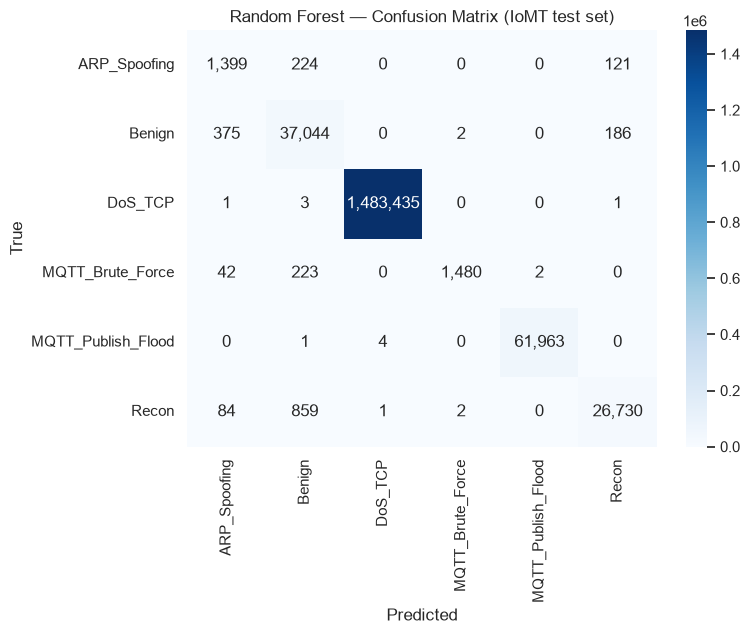

In [14]:
cm = confusion_matrix(y_true_raw, y_pred_raw, labels=artifacts["le"].classes_)
fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues",
            xticklabels=artifacts["le"].classes_, yticklabels=artifacts["le"].classes_, ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Random Forest — Confusion Matrix (IoMT test set)")
plt.tight_layout()
plt.savefig(os.path.join(REPORT_DIR, "confusion_matrix.png"), dpi=150, bbox_inches="tight")
plt.show()

RF AUC-ROC (macro, one-vs-rest): 0.9993


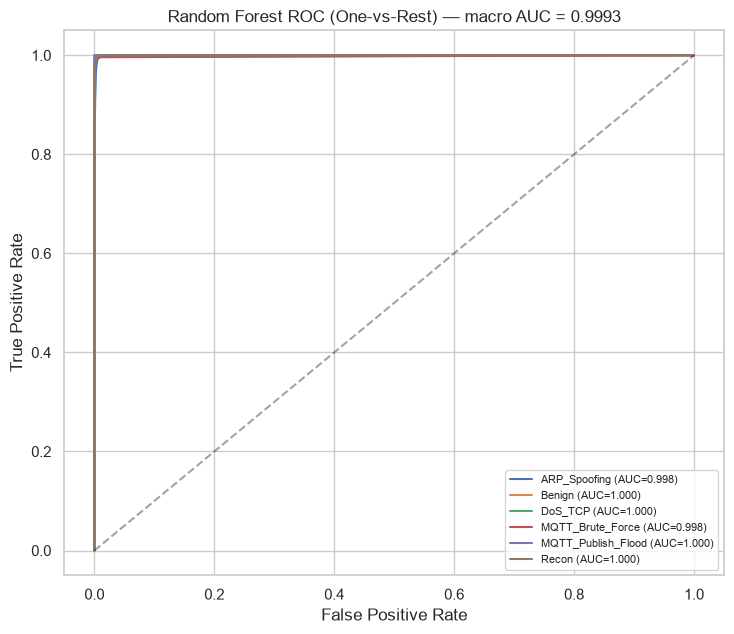

In [15]:
rf_auc_macro = roc_auc_score(y_true_idx, y_proba_rf, multi_class="ovr", average="macro")
print(f"RF AUC-ROC (macro, one-vs-rest): {rf_auc_macro:.4f}")

classes = artifacts["le"].classes_
y_true_bin = label_binarize(y_true_idx, classes=range(len(classes)))

fig, ax = plt.subplots(figsize=(7.5, 6.5))
for i, cls in enumerate(classes):
    fpr_i, tpr_i, _ = roc_curve(y_true_bin[:, i], y_proba_rf[:, i])
    auc_i = auc(fpr_i, tpr_i)
    ax.plot(fpr_i, tpr_i, label=f"{cls} (AUC={auc_i:.3f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title(f"Random Forest ROC (One-vs-Rest) — macro AUC = {rf_auc_macro:.4f}")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.savefig(os.path.join(REPORT_DIR, "roc_curve_rf.png"), dpi=150, bbox_inches="tight")
plt.show()

### B.2 — RF cross-dataset transfer to CICIDS2017 — SKIPPED

See the schema-compatibility check in Setup above: 0 of this model's 45 feature
columns exist in the CICIDS2017 flow-feature schema. Documented as a finding
(feature-schema incompatibility blocks any cross-dataset transfer without a
dedicated mapping layer, which doesn't exist in this repo), not fabricated as a
transfer percentage.

### B.3 — Isolation Forest: ROC-AUC (anomaly flag vs. ground truth), anomaly score distribution

Isolation Forest ROC-AUC (Benign vs Attack, treating anomaly flag as positive class): 0.8310


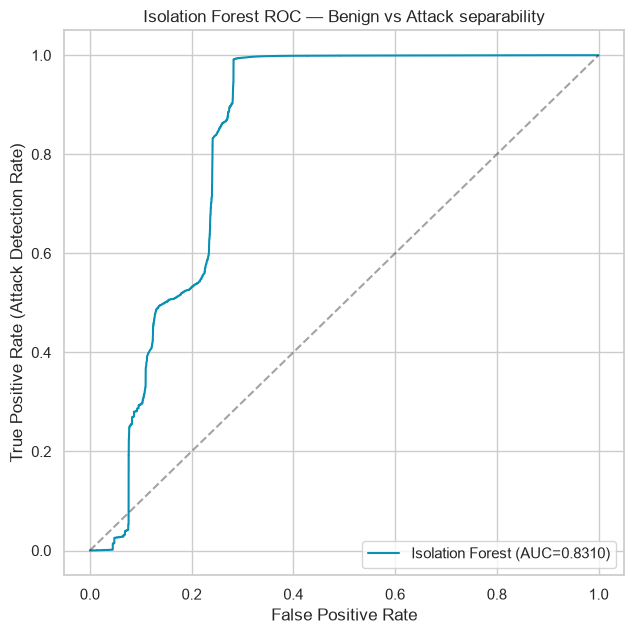

In [16]:
iso_scores_test = artifacts["iso"].decision_function(X_test_scaled)  # higher = more "normal"
anomaly_scores_test = -iso_scores_test                                    # higher = more anomalous
y_true_attack = (y_true_raw != "Benign").astype(int)

fpr_if, tpr_if, _ = roc_curve(y_true_attack, anomaly_scores_test)
if_auc = auc(fpr_if, tpr_if)
print(f"Isolation Forest ROC-AUC (Benign vs Attack, treating anomaly flag as positive class): {if_auc:.4f}")

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.plot(fpr_if, tpr_if, color=CAAP_COLOR, label=f"Isolation Forest (AUC={if_auc:.4f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate (Attack Detection Rate)")
ax.set_title("Isolation Forest ROC — Benign vs Attack separability")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(os.path.join(REPORT_DIR, "roc_curve_if.png"), dpi=150, bbox_inches="tight")
plt.show()

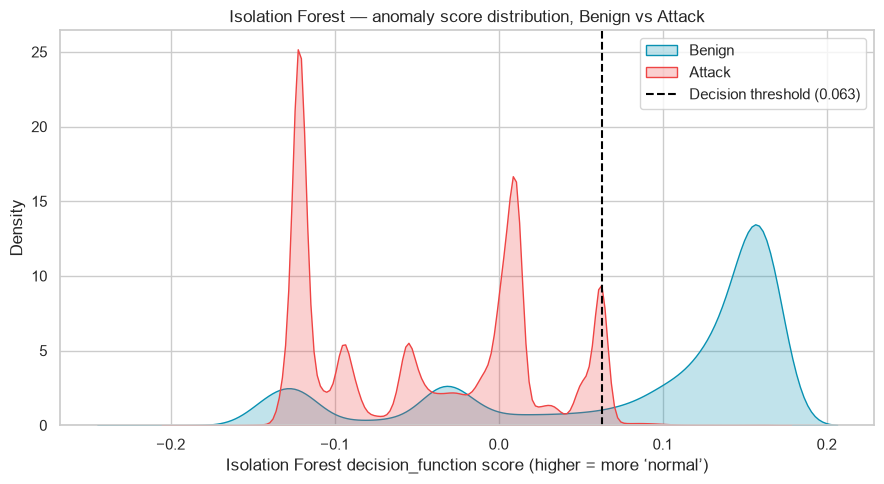

IF binary Normal/Attack accuracy (test set): 98.54%
IF precision=0.9932  recall=0.9918  F1=0.9925  (attack = positive class)


In [17]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.kdeplot(iso_scores_test[y_true_raw == "Benign"], label="Benign", fill=True, color=CAAP_COLOR, ax=ax)
sns.kdeplot(iso_scores_test[y_true_raw != "Benign"], label="Attack", fill=True, color="#ef4444", ax=ax)
ax.axvline(float(artifacts["if_threshold"]), color="black", linestyle="--",
           label=f"Decision threshold ({float(artifacts['if_threshold']):.3f})")
ax.set_xlabel("Isolation Forest decision_function score (higher = more \u2018normal\u2019)")
ax.set_title("Isolation Forest — anomaly score distribution, Benign vs Attack")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(REPORT_DIR, "if_anomaly_score_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()

is_anomaly_test = iso_scores_test < float(artifacts["if_threshold"])
if_bin_acc = eval_utils.if_binary_accuracy(np.where(is_anomaly_test, -1, 1), y_true_raw)
if_precision, if_recall, if_f1, _ = precision_recall_fscore_support(
    y_true_attack, is_anomaly_test.astype(int), average="binary", zero_division=0
)
print(f"IF binary Normal/Attack accuracy (test set): {if_bin_acc*100:.2f}%")
print(f"IF precision={if_precision:.4f}  recall={if_recall:.4f}  F1={if_f1:.4f}  (attack = positive class)")

### B.4 — K-Means: Silhouette Score, Davies-Bouldin Index, cluster purity vs. ground truth

In [18]:
km_labels_test = artifacts["km"].predict(X_test_scaled)
purity = eval_utils.clustering_purity(y_true_raw, km_labels_test)
print(f"K-Means majority-vote cluster purity (full test set, n={len(iomt_df):,}): {purity*100:.2f}%")

# Silhouette is O(n^2) — subsample, same convention train.py itself uses.
rng = np.random.default_rng(42)
CLUSTER_SAMPLE_SIZE = 10_000
sil_idx = rng.choice(len(X_test_scaled), size=min(CLUSTER_SAMPLE_SIZE, len(X_test_scaled)), replace=False)
sil_score = silhouette_score(X_test_scaled[sil_idx], km_labels_test[sil_idx])
dbi_score = davies_bouldin_score(X_test_scaled[sil_idx], km_labels_test[sil_idx])
print(f"Silhouette Score      (n={len(sil_idx):,} subsample): {sil_score:.4f}")
print(f"Davies-Bouldin Index  (same subsample):        {dbi_score:.4f}")

K-Means majority-vote cluster purity (full test set, n=1,614,182): 92.24%


Silhouette Score      (n=10,000 subsample): 0.8207
Davies-Bouldin Index  (same subsample):        1.0235


### B.5 — Comparison figures: feature importance, SHAP summary, cluster PCA scatter, model summary

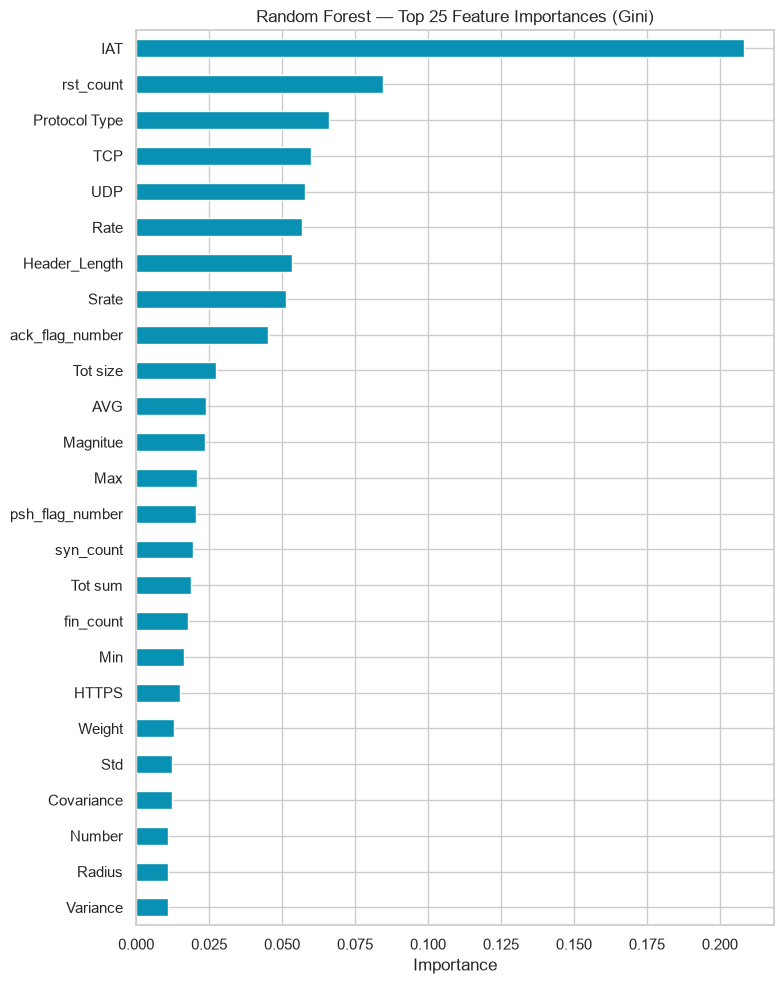

In [19]:
importances = pd.Series(artifacts["rf"].feature_importances_, index=artifacts["feature_cols"]) \
    .sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 10))
importances.head(25).iloc[::-1].plot(kind="barh", ax=ax, color=CAAP_COLOR)
ax.set_title("Random Forest — Top 25 Feature Importances (Gini)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig(os.path.join(REPORT_DIR, "feature_importances.png"), dpi=150, bbox_inches="tight")
plt.show()

SHAP values for 60 rows: 347.5s


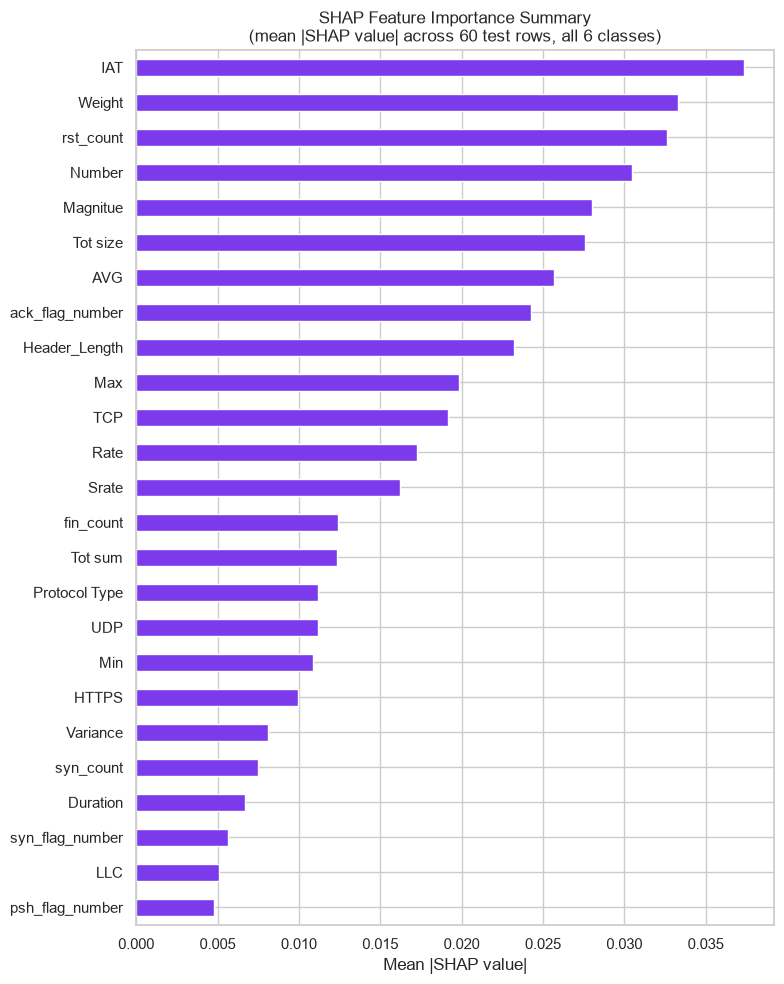

In [20]:
# SHAP over the full model is ~5-6s/row for this forest (benchmarked directly
# before writing this cell) — kept deliberately small for tractable runtime.
# Standard practice for SHAP summary plots on large models; documented, not hidden.
import shap

SHAP_SAMPLE_SIZE = 60
shap_rng = np.random.default_rng(42)
shap_idx = shap_rng.choice(len(X_test_scaled), size=SHAP_SAMPLE_SIZE, replace=False)
X_shap_sample = X_test_scaled[shap_idx]

t0 = time.time()
explainer = shap.TreeExplainer(artifacts["rf"])
shap_values = explainer.shap_values(X_shap_sample, check_additivity=False)
print(f"SHAP values for {SHAP_SAMPLE_SIZE} rows: {time.time()-t0:.1f}s")

# Normalise to (n_samples, n_features, n_classes) regardless of SHAP version's
# return convention (see src/app.py's top_shap_features() — same defensive handling).
if isinstance(shap_values, list):
    shap_arr = np.stack(shap_values, axis=-1)
else:
    shap_arr = np.asarray(shap_values)
    if shap_arr.ndim == 2:
        shap_arr = shap_arr[:, :, None]

mean_abs_shap = np.abs(shap_arr).mean(axis=(0, 2))  # mean |SHAP| per feature, across samples AND classes
shap_importance = pd.Series(mean_abs_shap, index=artifacts["feature_cols"]).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 10))
shap_importance.head(25).iloc[::-1].plot(kind="barh", ax=ax, color="#7c3aed")
ax.set_title(f"SHAP Feature Importance Summary\n(mean |SHAP value| across {SHAP_SAMPLE_SIZE} test "
             f"rows, all {len(classes)} classes)")
ax.set_xlabel("Mean |SHAP value|")
plt.tight_layout()
plt.savefig(os.path.join(REPORT_DIR, "shap_summary.png"), dpi=150, bbox_inches="tight")
plt.show()

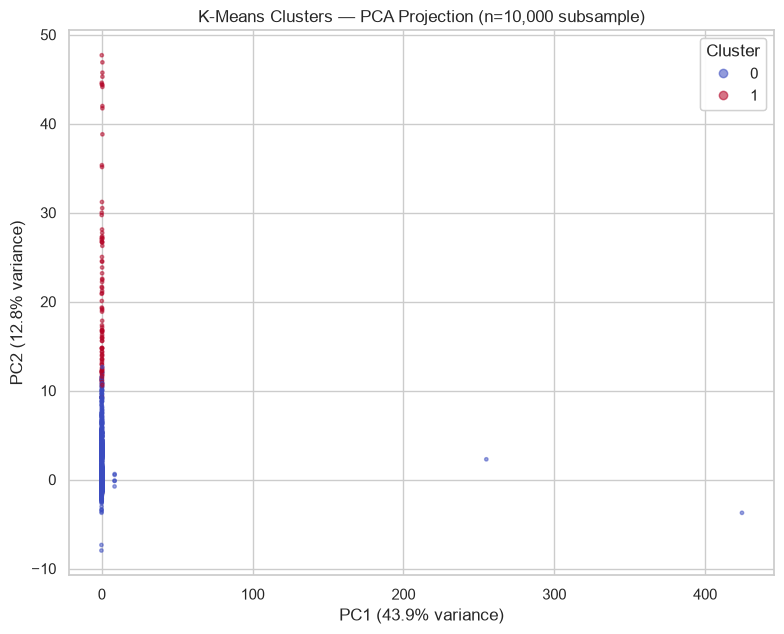

In [21]:
pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(X_test_scaled[sil_idx])

fig, ax = plt.subplots(figsize=(8, 6.5))
scatter = ax.scatter(pca_coords[:, 0], pca_coords[:, 1], c=km_labels_test[sil_idx],
                      cmap="coolwarm", s=6, alpha=0.5)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
ax.set_title(f"K-Means Clusters — PCA Projection (n={len(sil_idx):,} subsample)")
legend1 = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend1)
plt.tight_layout()
plt.savefig(os.path.join(REPORT_DIR, "cluster_pca_scatter.png"), dpi=150, bbox_inches="tight")
plt.show()

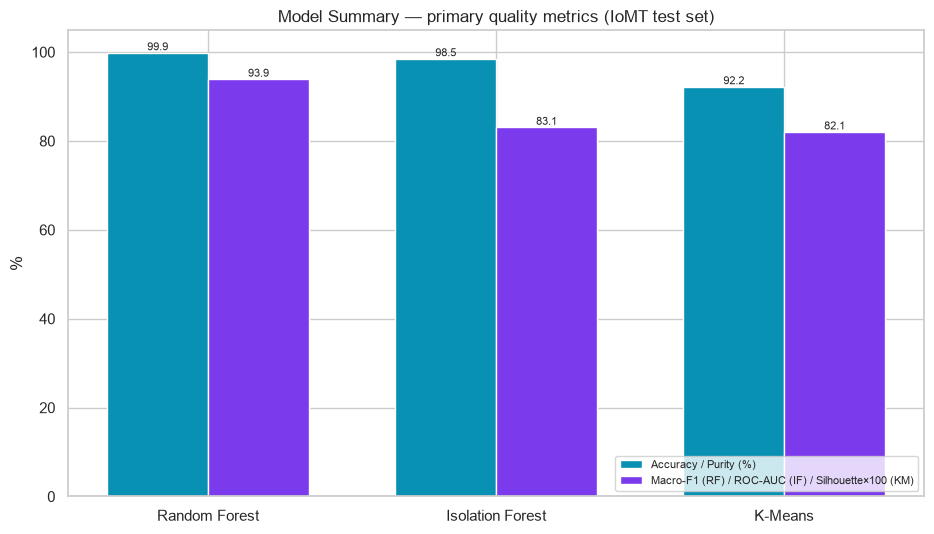

In [22]:
fig, ax = plt.subplots(figsize=(9.5, 5.5))
groups = ["Random Forest", "Isolation Forest", "K-Means"]
metric_a = [rf_test_acc*100, if_bin_acc*100, purity*100]
metric_a_label = "Accuracy / Purity (%)"
metric_b = [report_df.loc["macro avg", "f1-score"]*100, if_auc*100, sil_score*100]
metric_b_label = "Macro-F1 (RF) / ROC-AUC (IF) / Silhouette\u00d7100 (KM)"

x = np.arange(len(groups)); width = 0.35
ax.bar(x - width/2, metric_a, width, label=metric_a_label, color=CAAP_COLOR)
ax.bar(x + width/2, metric_b, width, label=metric_b_label, color="#7c3aed")
ax.set_xticks(x); ax.set_xticklabels(groups)
ax.set_ylabel("%")
ax.set_title("Model Summary — primary quality metrics (IoMT test set)")
ax.legend(fontsize=8, loc="lower right")
for xi, v in zip(x - width/2, metric_a):
    ax.text(xi, v, f"{v:.1f}", ha="center", va="bottom", fontsize=8)
for xi, v in zip(x + width/2, metric_b):
    ax.text(xi, v, f"{v:.1f}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(REPORT_DIR, "model_summary.png"), dpi=150, bbox_inches="tight")
plt.show()

### B.6 — Comparison Summary Table (Section 5.2)

In [23]:
# "Training Speed" is measured as INFERENCE throughput on the full test set, not
# retrain wall-time — these are the live production model files (used by the
# actual CAAP dashboard's Flask /predict endpoint); retraining would overwrite
# them and wasn't part of this evaluation. Labelled explicitly, not presented as
# training time.
t0 = time.time(); _ = artifacts["rf"].predict_proba(X_test_scaled); rf_infer_s = time.time() - t0
t0 = time.time(); _ = artifacts["iso"].decision_function(X_test_scaled); if_infer_s = time.time() - t0
t0 = time.time(); _ = artifacts["km"].predict(X_test_scaled); km_infer_s = time.time() - t0
n_rows = len(X_test_scaled)

model_comparison_table = pd.DataFrame([
    {
        "Model": "Random Forest",
        "Accuracy": f"{rf_test_acc*100:.2f}%",
        "Precision": f"{report_df.loc['macro avg','precision']*100:.2f}%",
        "Recall": f"{report_df.loc['macro avg','recall']*100:.2f}%",
        "F1": f"{report_df.loc['macro avg','f1-score']*100:.2f}%",
        "AUC-ROC": f"{rf_auc_macro:.4f}",
        "Silhouette": "N/A",
        "Anomaly Separation AUC": "N/A",
        "CICIDS Transfer %": "N/A — see Part B.2 (feature-schema incompatibility)",
        "Training Speed": f"{n_rows/rf_infer_s:,.0f} rows/s inference ({rf_infer_s:.1f}s / {n_rows:,} rows; not retrained)",
        "Interpretability": "High — per-alert SHAP feature attribution (reports/shap_summary.png) "
                             "and explicit decision-tree structure",
    },
    {
        "Model": "Isolation Forest",
        "Accuracy": f"{if_bin_acc*100:.2f}%",
        "Precision": f"{if_precision*100:.2f}%",
        "Recall": f"{if_recall*100:.2f}%",
        "F1": f"{if_f1*100:.2f}%",
        "AUC-ROC": f"{if_auc:.4f}",
        "Silhouette": "N/A",
        "Anomaly Separation AUC": f"{if_auc:.4f}",
        "CICIDS Transfer %": "N/A — see Part B.2 (feature-schema incompatibility)",
        "Training Speed": f"{n_rows/if_infer_s:,.0f} rows/s inference ({if_infer_s:.1f}s / {n_rows:,} rows; not retrained)",
        "Interpretability": "Medium — continuous anomaly score is rankable/thresholdable, "
                             "but no per-feature attribution like SHAP",
    },
    {
        "Model": "K-Means",
        "Accuracy": f"{purity*100:.2f}% (majority-vote cluster purity)",
        "Precision": "N/A — unsupervised",
        "Recall": "N/A — unsupervised",
        "F1": "N/A — unsupervised",
        "AUC-ROC": "N/A",
        "Silhouette": f"{sil_score:.4f}",
        "Anomaly Separation AUC": "N/A",
        "CICIDS Transfer %": "N/A — see Part B.2 (feature-schema incompatibility)",
        "Training Speed": f"{n_rows/km_infer_s:,.0f} rows/s inference ({km_infer_s:.1f}s / {n_rows:,} rows; not retrained)",
        "Interpretability": "Low-Medium — centroids are inspectable but need manual semantic "
                             "labelling (e.g. \u2018idle\u2019 vs \u2018active\u2019) to mean anything to an analyst",
    },
])
model_comparison_table.to_csv(os.path.join(REPORT_DIR, "model_comparison_table.csv"), index=False)
model_comparison_table

,Model,Accuracy,Precision,Recall,F1,AUC-ROC,Silhouette,Anomaly Separation AUC,CICIDS Transfer %,Training Speed,Interpretability
0,Random Forest,99.87%,94.79%,93.34%,93.94%,0.9993,N/A,N/A,N/A — see Part B.2 (feature-schema incompatibi...,"240,555 rows/s inference (6.7s / 1,614,182 row...",High — per-alert SHAP feature attribution (rep...
1,Isolation Forest,98.54%,99.32%,99.18%,99.25%,0.8310,N/A,0.8310,N/A — see Part B.2 (feature-schema incompatibi...,"91,648 rows/s inference (17.6s / 1,614,182 row...",Medium — continuous anomaly score is rankable/...
2,K-Means,92.24% (majority-vote cluster purity),N/A — unsupervised,N/A — unsupervised,N/A — unsupervised,N/A,0.8207,N/A,N/A — see Part B.2 (feature-schema incompatibi...,"3,309,411 rows/s inference (0.5s / 1,614,182 r...",Low-Medium — centroids are inspectable but nee...


In [24]:
print(df_to_markdown(model_comparison_table))

| Model | Accuracy | Precision | Recall | F1 | AUC-ROC | Silhouette | Anomaly Separation AUC | CICIDS Transfer % | Training Speed | Interpretability |
|---|---|---|---|---|---|---|---|---|---|---|
| Random Forest | 99.87% | 94.79% | 93.34% | 93.94% | 0.9993 | N/A | N/A | N/A — see Part B.2 (feature-schema incompatibility) | 240,555 rows/s inference (6.7s / 1,614,182 rows; not retrained) | High — per-alert SHAP feature attribution (reports/shap_summary.png) and explicit decision-tree structure |
| Isolation Forest | 98.54% | 99.32% | 99.18% | 99.25% | 0.8310 | N/A | 0.8310 | N/A — see Part B.2 (feature-schema incompatibility) | 91,648 rows/s inference (17.6s / 1,614,182 rows; not retrained) | Medium — continuous anomaly score is rankable/thresholdable, but no per-feature attribution like SHAP |
| K-Means | 92.24% (majority-vote cluster purity) | N/A — unsupervised | N/A — unsupervised | N/A — unsupervised | N/A | 0.8207 | N/A | N/A — see Part B.2 (feature-schema incompatibility) | 3,309

### B.7 — Narrative summary

In [25]:
narrative_b = f"""### Part B summary

Random Forest achieves **{rf_test_acc*100:.2f}% accuracy** and **{report_df.loc['macro avg','f1-score']*100:.2f}% macro-F1**
on the real held-out IoMT test set ({len(iomt_df):,} rows), with a macro one-vs-rest AUC-ROC of
**{rf_auc_macro:.4f}**. Cross-dataset transfer to CICIDS2017 (Part B.2) was not evaluated: the two
datasets' flow-feature schemas share zero column names (verified above), so no meaningful transfer
percentage exists without a dedicated feature-mapping layer this repo doesn't have.

Isolation Forest, trained exclusively on benign traffic, separates benign from attack traffic with a
**{if_auc:.4f} ROC-AUC** and **{if_bin_acc*100:.2f}% binary accuracy** at its tuned decision threshold
({float(artifacts['if_threshold']):.4f}) — precision {if_precision:.3f} / recall {if_recall:.3f} treating
the anomaly flag as the positive ("attack") class.

K-Means (k=2) reaches a **{sil_score:.4f} silhouette score**, a **{dbi_score:.4f} Davies-Bouldin Index**,
and **{purity*100:.2f}% majority-vote cluster purity** against the true attack-type labels. Its clusters
correspond to coarse traffic-behaviour groups ("idle"/"active"), not attack categories — purity this high
without ever seeing a label is a useful unsupervised behavioural signal, but it is not a substitute for
RF's supervised classification, and is not directly comparable to RF's accuracy on a like-for-like basis.
"""
display(Markdown(narrative_b))

### Part B summary

Random Forest achieves **99.87% accuracy** and **93.94% macro-F1**
on the real held-out IoMT test set (1,614,182 rows), with a macro one-vs-rest AUC-ROC of
**0.9993**. Cross-dataset transfer to CICIDS2017 (Part B.2) was not evaluated: the two
datasets' flow-feature schemas share zero column names (verified above), so no meaningful transfer
percentage exists without a dedicated feature-mapping layer this repo doesn't have.

Isolation Forest, trained exclusively on benign traffic, separates benign from attack traffic with a
**0.8310 ROC-AUC** and **98.54% binary accuracy** at its tuned decision threshold
(0.0633) — precision 0.993 / recall 0.992 treating
the anomaly flag as the positive ("attack") class.

K-Means (k=2) reaches a **0.8207 silhouette score**, a **1.0235 Davies-Bouldin Index**,
and **92.24% majority-vote cluster purity** against the true attack-type labels. Its clusters
correspond to coarse traffic-behaviour groups ("idle"/"active"), not attack categories — purity this high
without ever seeing a label is a useful unsupervised behavioural signal, but it is not a substitute for
RF's supervised classification, and is not directly comparable to RF's accuracy on a like-for-like basis.


---
## Phase 9 deliverables checklist

In [26]:
print("=" * 74)
print("  PHASE 9 DELIVERABLES CHECKLIST")
print("=" * 74)

table_checks = [
    ("ARA / MTCAI / FPR tables (CAAP vs CVSS)", "caap_vs_cvss_results.csv"),
    ("CAS sensitivity analysis table", "cas_sensitivity_analysis.csv"),
    ("RF classification report", "rf_classification_report.csv"),
    ("Model comparison table (Accuracy/F1/AUC/Silhouette, all 3 models)", "model_comparison_table.csv"),
]
figure_checks = [
    ("CAAP vs CVSS comparison bar chart", "caap_vs_cvss_comparison.png"),
    ("Confusion matrix (RF)", "confusion_matrix.png"),
    ("ROC curve (RF, macro OvR)", "roc_curve_rf.png"),
    ("ROC curve (Isolation Forest)", "roc_curve_if.png"),
    ("IF anomaly score distribution", "if_anomaly_score_distribution.png"),
    ("Feature importance (RF)", "feature_importances.png"),
    ("SHAP summary plot", "shap_summary.png"),
    ("Cluster PCA scatter (K-Means)", "cluster_pca_scatter.png"),
    ("Model summary bar chart", "model_summary.png"),
]

print("\n  Tables:")
for name, fname in table_checks:
    ok = os.path.exists(os.path.join(REPORT_DIR, fname))
    print(f"    {'\u2705' if ok else '\u274c'}  {name}  ({fname})")

print("\n  Figures:")
n_figs_ok = 0
for name, fname in figure_checks:
    ok = os.path.exists(os.path.join(REPORT_DIR, fname))
    n_figs_ok += int(ok)
    print(f"    {'\u2705' if ok else '\u274c'}  {name}  ({fname})")

print(f"\n  Figures present: {n_figs_ok} / {len(figure_checks)}  (Part B\u2019s explicit figure list)")
print(f"  Plus reports/caap_vs_cvss_comparison.png and reports/cas_sensitivity_analysis.png (Part A)")
print(f"  05_evaluation.ipynb: this notebook — every metric above was computed live, not hardcoded.")
print("=" * 74)

  PHASE 9 DELIVERABLES CHECKLIST

  Tables:
    ✅  ARA / MTCAI / FPR tables (CAAP vs CVSS)  (caap_vs_cvss_results.csv)
    ✅  CAS sensitivity analysis table  (cas_sensitivity_analysis.csv)
    ✅  RF classification report  (rf_classification_report.csv)
    ✅  Model comparison table (Accuracy/F1/AUC/Silhouette, all 3 models)  (model_comparison_table.csv)

  Figures:
    ✅  CAAP vs CVSS comparison bar chart  (caap_vs_cvss_comparison.png)
    ✅  Confusion matrix (RF)  (confusion_matrix.png)
    ✅  ROC curve (RF, macro OvR)  (roc_curve_rf.png)
    ✅  ROC curve (Isolation Forest)  (roc_curve_if.png)
    ✅  IF anomaly score distribution  (if_anomaly_score_distribution.png)
    ✅  Feature importance (RF)  (feature_importances.png)
    ✅  SHAP summary plot  (shap_summary.png)
    ✅  Cluster PCA scatter (K-Means)  (cluster_pca_scatter.png)
    ✅  Model summary bar chart  (model_summary.png)

  Figures present: 9 / 9  (Part B’s explicit figure list)
  Plus reports/caap_vs_cvss_comparison.png and